In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../datasets/Student_Performance.csv")
print(df.shape)
print(df.head())


(10000, 6)
   Hours Studied  Previous Scores Extracurricular Activities  Sleep Hours  \
0              7               99                        Yes            9   
1              4               82                         No            4   
2              8               51                        Yes            7   
3              5               52                        Yes            5   
4              7               75                         No            8   

   Sample Question Papers Practiced  Performance Index  
0                                 1               91.0  
1                                 2               65.0  
2                                 2               45.0  
3                                 2               36.0  
4                                 5               66.0  


In [23]:
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())
print("\nBasic stats:")
print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  str    
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), str(1)
memory usage: 468.9 KB
None

Missing values:
Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

Basic stats:
       Hours Studied  Previous Scores   Sleep Hours  \
count   

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_5320\2880788347.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Extracurricular Activities', y='Performance Index', data=df, palette='Set2')


ValueError: could not convert string to float: 'Yes'

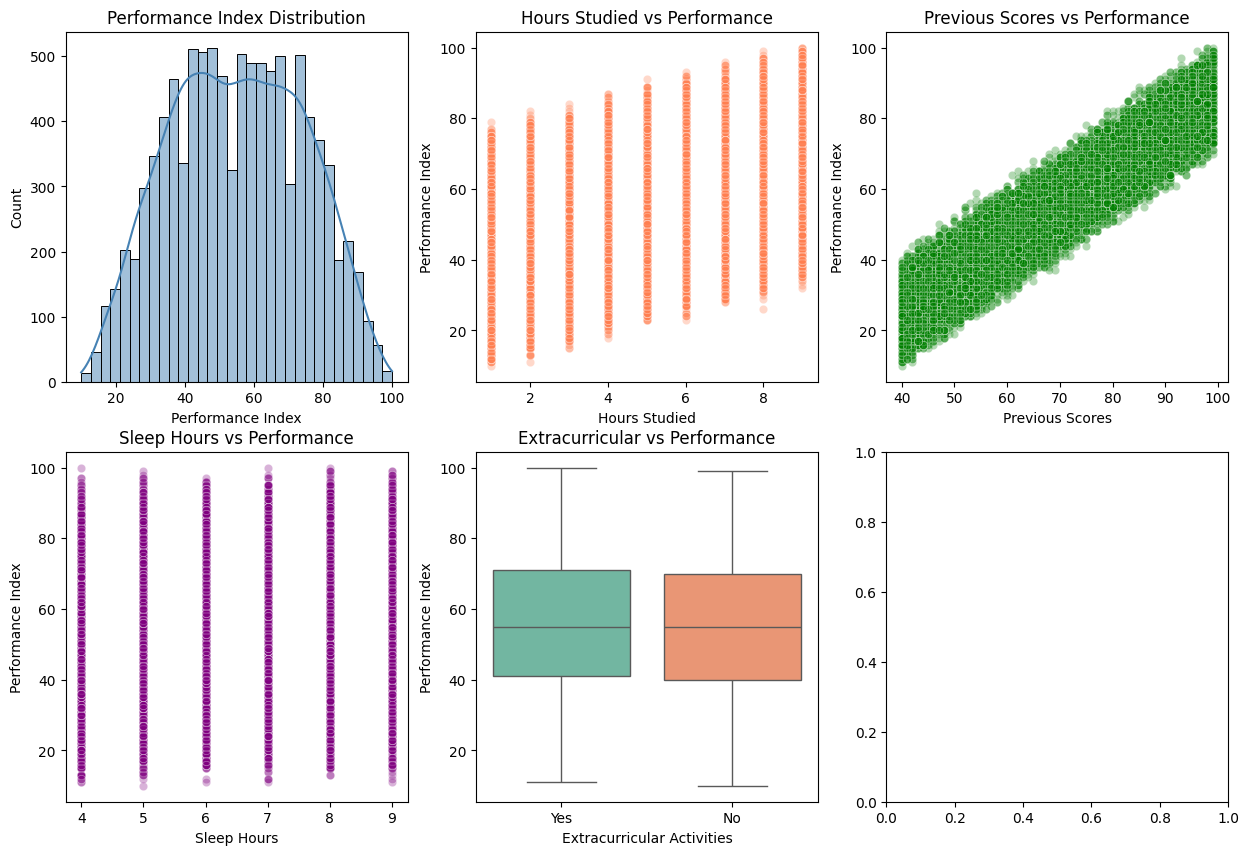

In [24]:
plt.figure(figsize=(15, 10))

# 1. Performance Index distribution
plt.subplot(2, 3, 1)
sns.histplot(df['Performance Index'], kde=True, color='steelblue')
plt.title('Performance Index Distribution')

# 2. Hours Studied vs Performance
plt.subplot(2, 3, 2)
sns.scatterplot(x='Hours Studied', y='Performance Index', data=df, color='coral', alpha=0.3)
plt.title('Hours Studied vs Performance')

# 3. Previous Scores vs Performance
plt.subplot(2, 3, 3)
sns.scatterplot(x='Previous Scores', y='Performance Index', data=df, color='green', alpha=0.3)
plt.title('Previous Scores vs Performance')

# 4. Sleep Hours vs Performance
plt.subplot(2, 3, 4)
sns.scatterplot(x='Sleep Hours', y='Performance Index', data=df, color='purple', alpha=0.3)
plt.title('Sleep Hours vs Performance')

# 5. Extracurricular vs Performance
plt.subplot(2, 3, 5)
sns.boxplot(x='Extracurricular Activities', y='Performance Index', data=df, palette='Set2')
plt.title('Extracurricular vs Performance')

# 6. Correlation heatmap
plt.subplot(2, 3, 6)
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')

plt.tight_layout()
plt.savefig('../notebooks/student_performance_eda.png', dpi=150)
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from xgboost import XGBRegressor
import joblib

X = df.drop('Performance Index', axis=1)
y = df['Performance Index']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42)
}

best_model = None
best_r2 = 0

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    print(f"{name} → R²: {r2:.4f} | RMSE: {rmse:.4f}")
    if r2 > best_r2:
        best_r2 = r2
        best_model = model
        best_name = name

print(f"\nBest model: {best_name} with R²: {best_r2:.4f}")

# Save best model
joblib.dump(best_model, '../models/productivity_model.pkl')
print("Model saved!")

Linear Regression → R²: 0.9890 | RMSE: 2.0206
Random Forest → R²: 0.9861 | RMSE: 2.2713
XGBoost → R²: 0.9867 | RMSE: 2.2194

Best model: Linear Regression with R²: 0.9890
Model saved!


In [ ]:
# Feature engineering
df['Work_Leisure_Ratio'] = df['Daily Work Hours'] / (df['Daily Leisure Hours'] + 0.1)
df['Active_Hours'] = df['Daily Work Hours'] + (df['Daily Exercise Minutes'] / 60)
df['Screen_Work_Ratio'] = df['Screen Time (hours)'] / (df['Daily Work Hours'] + 0.1)
df['Sleep_Quality'] = df['Daily Sleep Hours'] / 8  # 8 hours = ideal

# Retrain with new features
X = df.drop(['User ID', 'Productivity Score'], axis=1)
y = df['Productivity Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    print(f"{name} → R²: {r2:.4f} | RMSE: {rmse:.4f}")

Linear Regression → R²: 0.0681 | RMSE: 11.5165
Random Forest → R²: 0.3502 | RMSE: 9.6167
XGBoost → R²: 0.1726 | RMSE: 10.8515
